In [ ]:
#Pawel Maczuga and Maciej Paszynski (2023)
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from functools import partial
# from google.colab import files
import time
import os
from typing import Tuple
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Parameters

In [2]:
def load_and_scale_kq(path):
    kq_layer = np.load(path)
    log_kq = np.log10(kq_layer + 1e-6)
    max_scale = 10.0
    l_min, l_max = log_kq.min(), log_kq.max()
    k_scaled = (log_kq - l_min) / (l_max - l_min) * (max_scale - 1.0) + 1.0
    scale = (1.0, max_scale)
    return k_scaled, scale

In [4]:
DATA_PATH = 'C:\PINN_mgr\FEniCS\solver-validation-newton-method\data\spe_model2_layer50.npy'
kq_data_matrix, scale = load_and_scale_kq(DATA_PATH)
ACTUAL_NY, ACTUAL_NX = kq_data_matrix.shape
REAL_NX = ACTUAL_NX
REAL_NY = ACTUAL_NY

FT_TO_M = 0.3048
REAL_LX = REAL_NX * 20.0 * FT_TO_M
REAL_LY = REAL_NY * 10.0 * FT_TO_M

In [ ]:
TOTAL_TIME = 1000.                
N_POINTS_X = REAL_NX  
N_POINTS_Y = REAL_NY  
DT = 1.0
# N_POINTS_T = int(TOTAL_TIME/DT)
N_POINTS_T = 100

x_domain = [0.0, REAL_LX]
y_domain = [0.0, REAL_LY]
t_domain = [0.0, TOTAL_TIME]

WEIGHT_RESIDUAL = 1.0           # Weight of residual part of loss function
WEIGHT_INITIAL = 1.0            # Weight of initial part of loss function
WEIGHT_BOUNDARY = 1.0           # Weight of boundary part of loss function

LAYERS = 4
NEURONS_PER_LAYER = 80
EPOCHS = 20_000
LEARNING_RATE = 0.0005

## Initial condition

In [ ]:
def initial_condition(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    mid_x = REAL_LX / 2.0
    mid_y = REAL_LY / 2.0

    r = torch.sqrt((x - mid_x)**2 + (y - mid_y)**2)
    return (r <= 30.0).float()

## PINN


In [ ]:
class PINN(nn.Module):
    """Simple neural network accepting two features as input and returning a single output

    In the context of PINNs, the neural network is used as universal function approximator
    to approximate the solution of the differential equation
    """
    def __init__(self, num_hidden: int, dim_hidden: int, act=nn.Tanh()):

        super().__init__()

        self.layer_in = nn.Linear(3, dim_hidden)
        self.layer_out = nn.Linear(dim_hidden, 1)

        num_middle = num_hidden - 1
        self.middle_layers = nn.ModuleList(
            [nn.Linear(dim_hidden, dim_hidden) for _ in range(num_middle)]
        )
        self.act = act

    def forward(self, x, y, t):

        # x_stack = torch.cat([x, y, t], dim=1)
        #normalizacja 
        x_norm = x / REAL_LX
        y_norm = y / REAL_LY
        t_norm = t / TOTAL_TIME

        x_stack = torch.cat([x_norm, y_norm, t_norm], dim=1)
        out = self.act(self.layer_in(x_stack))
        for layer in self.middle_layers:
            out = self.act(layer(out))
        logits = self.layer_out(out)

        return logits

    def device(self):
        return next(self.parameters()).device


def f(pinn: PINN, x: torch.Tensor, y: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
    """Compute the value of the approximate solution from the NN model"""
    return pinn(x, y, t)


def df(output: torch.Tensor, input: torch.Tensor, order: int = 1) -> torch.Tensor:
    """Compute neural network derivative with respect to input features using PyTorch autograd engine"""
    df_value = output
    for _ in range(order):
        df_value = torch.autograd.grad(
            df_value,
            input,
            grad_outputs=torch.ones_like(input),
            create_graph=True,
            retain_graph=True,
        )[0]

    return df_value


def dfdt(pinn: PINN, x: torch.Tensor, y: torch.Tensor, t: torch.Tensor, order: int = 1):
    f_value = f(pinn, x, y, t)
    return df(f_value, t, order=order)


def dfdx(pinn: PINN, x: torch.Tensor, y: torch.Tensor, t: torch.Tensor, order: int = 1):
    f_value = f(pinn, x, y, t)
    return df(f_value, x, order=order)

def dfdy(pinn: PINN, x: torch.Tensor, y: torch.Tensor, t: torch.Tensor, order: int = 1):
    f_value = f(pinn, x, y, t)
    return df(f_value, y, order=order)

## Loss function

In [ ]:
from turtle import down


def get_boundary_points(x_domain, y_domain, t_domain, device = torch.device("cpu"), requires_grad=True):
    """
         .+------+
       .' |    .'|
      +---+--+'  |
      |   |  |   |
    y |  ,+--+---+
      |.'    | .' t
      +------+'
         x
    """
    x_linspace = torch.linspace(x_domain[0], x_domain[1], N_POINTS_X, device=device)
    y_linspace = torch.linspace(y_domain[0], y_domain[1], N_POINTS_Y, device=device)
    t_linspace = torch.linspace(t_domain[0], t_domain[1], N_POINTS_T, device=device)

    #poziom

    x_grid_h, t_grid_h = torch.meshgrid( x_linspace, t_linspace, indexing="ij")
    x_grid_h = x_grid_h.reshape(-1, 1)
    t_grid_h = t_grid_h.reshape(-1, 1)

    y0 = torch.full_like(t_grid_h, y_domain[0], requires_grad=requires_grad)
    y1 = torch.full_like(t_grid_h, y_domain[1], requires_grad=requires_grad)

    if requires_grad:
        x_grid_h.requires_grad = True
        t_grid_h.requires_grad = True

    #pion
    y_grid_v, t_grid_v = torch.meshgrid( y_linspace, t_linspace, indexing="ij")
    y_grid_v = y_grid_v.reshape(-1, 1)
    t_grid_v = t_grid_v.reshape(-1, 1)

    x0 = torch.full_like(t_grid_v, x_domain[0], requires_grad=requires_grad)
    x1 = torch.full_like(t_grid_v, x_domain[1], requires_grad=requires_grad)

    if requires_grad:
        y_grid_v.requires_grad = True
        t_grid_v.requires_grad = True

    down  = (x_grid_h, y0,       t_grid_h)
    up    = (x_grid_h, y1,       t_grid_h)
    left  = (x0,       y_grid_v, t_grid_v)
    right = (x1,       y_grid_v, t_grid_v)

    return down, up, left, right

In [ ]:
def get_initial_points(x_domain, y_domain, t_domain, device = torch.device("cpu"), requires_grad=True):
    x_linspace = torch.linspace(x_domain[0], x_domain[1], N_POINTS_X)
    y_linspace = torch.linspace(y_domain[0], y_domain[1], N_POINTS_Y)
    
    x_grid, y_grid = torch.meshgrid( x_linspace, y_linspace, indexing="ij")
    x_grid = x_grid.reshape(-1, 1)
    y_grid = y_grid.reshape(-1, 1)
    t0 = torch.full_like(x_grid, t_domain[0])

    if requires_grad:
        x_grid.requires_grad = True
        y_grid.requires_grad = True
        t0.requires_grad = True

    return (x_grid, y_grid, t0)

In [ ]:
def get_interior_points(x_domain, y_domain, t_domain, device = torch.device("cpu"), requires_grad=True):
    x_raw = torch.linspace(x_domain[0], x_domain[1], steps=N_POINTS_X)
    y_raw = torch.linspace(y_domain[0], y_domain[1], steps=N_POINTS_Y)
    t_raw = torch.linspace(t_domain[0], t_domain[1], steps=N_POINTS_T)
    grids = torch.meshgrid(x_raw, y_raw, t_raw, indexing="ij")

    x = grids[0].reshape(-1, 1) 
    y = grids[1].reshape(-1, 1) 
    t = grids[2].reshape(-1, 1) 

    if requires_grad:
        x.requires_grad = True
        y.requires_grad = True
        t.requires_grad = True  

    return x, y, t

In [ ]:
KQ_TENSOR = torch.tensor(kq_data_matrix, dtype=torch.float32).to(device)

In [ ]:
def Kq(x, y):
    x_norm = x / REAL_LX
    y_norm = y / REAL_LY
    
    idx_x = (x_norm * (REAL_NX - 1)).long()
    idx_y = (y_norm * (REAL_NY - 1)).long()

    idx_x = torch.clamp(idx_x, 0, REAL_NX - 1)
    idx_y = torch.clamp(idx_y, 0, REAL_NY - 1)

    return KQ_TENSOR[idx_y, idx_x]

def K(x, y, u):
    return Kq(x, y) * torch.exp(10.0 * u)

def source_term(name, x, y):
    if name == "h=0":
        return 0.0
    else:
        x_n = x / REAL_LX
        y_n = y / REAL_LY
        return 1.0 + torch.sin(2 * np.pi * x_n) * torch.sin(2 * np.pi * y_n)


In [ ]:
class Loss:
    def __init__(
        self,
        x_domain: Tuple[float, float],
        y_domain: Tuple[float, float],
        t_domain: Tuple[float, float],
        # n_points: int,
        initial_condition: Callable,
        weight_r: float = 1.0,
        weight_b: float = 1.0,
        weight_i: float = 1.0,
        verbose: bool = False,
    ):
        self.x_domain = x_domain
        self.y_domain = y_domain
        self.t_domain = t_domain
        # self.n_points = n_points
        self.initial_condition = initial_condition
        self.weight_r = weight_r
        self.weight_b = weight_b
        self.weight_i = weight_i

    def residual_loss(self, pinn: PINN):
        x, y, t = get_interior_points(self.x_domain, self.y_domain, self.t_domain, pinn.device())
        u = f(pinn, x, y, t)
        
        du_dx = dfdx(pinn, x, y, t)
        du_dy = dfdy(pinn, x, y, t)
        
        K_val = K(x, y, u)

        flux_x = K_val * du_dx
        flux_y = K_val * du_dy

        d_flux_x_dx = df(flux_x, x)
        d_flux_y_dy = df(flux_y, y)
        div_flux = d_flux_x_dx + d_flux_y_dy

        u_t = dfdt(pinn, x, y, t)
        source = source_term("h=1", x, y)
        res = u_t - div_flux - source

        return res.pow(2).mean()


    def initial_loss(self, pinn: PINN):
        x, y, t = get_initial_points(self.x_domain, self.y_domain, self.t_domain, pinn.device())
        pinn_init = self.initial_condition(x, y)
        loss = f(pinn, x, y, t) - pinn_init
        return loss.pow(2).mean()

    def boundary_loss(self, pinn: PINN):
        down, up, left, right = get_boundary_points(
            self.x_domain, self.y_domain, self.t_domain, pinn.device()
        )

        u_down  = f(pinn, *down)
        u_up    = f(pinn, *up)
        u_left  = f(pinn, *left)
        u_right = f(pinn, *right)
    
        loss = u_down.pow(2).mean() + \
               u_up.pow(2).mean()   + \
               u_left.pow(2).mean() + \
               u_right.pow(2).mean()

        return loss

    def verbose(self, pinn: PINN):
        """
        Returns all parts of the loss function

        Not used during training! Only for checking the results later.
        """
        residual_loss = self.residual_loss(pinn)
        initial_loss = self.initial_loss(pinn)
        boundary_loss = self.boundary_loss(pinn)

        final_loss = \
            self.weight_r * residual_loss + \
            self.weight_i * initial_loss + \
            self.weight_b * boundary_loss

        return final_loss, residual_loss, initial_loss, boundary_loss

    def __call__(self, pinn: PINN):
        """
        Allows you to use instance of this class as if it was a function:

        ```
            >>> loss = Loss(*some_args)
            >>> calculated_loss = loss(pinn)
        ```
        """
        return self.verbose(pinn)[0]

## Train function

In [ ]:
def train_model(
    nn_approximator: PINN,
    loss_fn: Callable,
    learning_rate: float = 0.01,
    max_epochs: int = 1_000
) -> Tuple[PINN, dict]:

    optimizer = torch.optim.Adam(nn_approximator.parameters(), lr=learning_rate)

    history = {
        'total': [],
        'residual': [],
        'initial': [],
        'boundary': []
    }

    for epoch in range(max_epochs):

        try:
            total_l, res_l, init_l, bnd_l = loss_fn.verbose(nn_approximator)
            optimizer.zero_grad()

            total_l.backward()
            optimizer.step()

            history['total'].append(total_l.detach().item())
            history['residual'].append(res_l.detach().item())
            history['initial'].append(init_l.detach().item())
            history['boundary'].append(bnd_l.detach().item())

            if (epoch + 1) % 1000 == 0:
                print(f"Epoch: {epoch + 1} - Total Loss: {total_l.item():.6f}")

        except KeyboardInterrupt:
            break

    return nn_approximator, history


In [ ]:
def get_pinn_map(model, t_value):
    model.eval()
    with torch.no_grad():
        x_linspace = torch.linspace(x_domain[0], x_domain[1], N_POINTS_X, device=device)
        y_linspace = torch.linspace(y_domain[0], y_domain[1], N_POINTS_Y, device=device)
        X, Y = torch.meshgrid(x_linspace, y_linspace, indexing="ij")
        
        T = torch.full_like(X, t_value)
        u_pred = model(X.reshape(-1, 1), Y.reshape(-1, 1), T.reshape(-1, 1))
        u_map = u_pred.reshape(N_POINTS_X, N_POINTS_Y).cpu().numpy()
        
        save_dir = Path("results/maps_to_compare")
        save_dir.mkdir(parents=True, exist_ok=True)

        file_path = save_dir / f"pinn_map_t{t_value}_NT{N_POINTS_T}_lr{LEARNING_RATE}_ep{EPOCHS}.npy"

        data_to_save = {
            "u_pinn": u_map,
            "t": t_value,
            "x_grid": X.cpu().numpy(),
            "y_grid": Y.cpu().numpy()
        }
        
        np.save(file_path, data_to_save)

        return u_map

## Plotting functions

In [12]:
def plot_solution(pinn: PINN, x: torch.Tensor, t: torch.Tensor, figsize=(8, 6), dpi=100):

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    x_raw = torch.unique(x).reshape(-1, 1)
    t_raw = torch.unique(t)

    def animate(i):

        if not i % 10 == 0:
            t_partial = torch.ones_like(x_raw) * t_raw[i]
            f_final = f(pinn, x_raw, t_partial)
            ax.clear()
            ax.plot(
                x_raw.detach().numpy(), f_final.detach().numpy(), label=f"Time {float(t[i])}"
            )
            ax.set_ylim(-1, 1)
            ax.legend()

    n_frames = t_raw.shape[0]
    return FuncAnimation(fig, animate, frames=n_frames, interval=100, repeat=False)

def plot_color(z: torch.Tensor, x: torch.Tensor, y: torch.Tensor, n_points_x, n_points_t, title, figsize=(8, 6), dpi=100, cmap="viridis"):
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    z_raw = z.detach().cpu().numpy()
    x_raw = x.detach().cpu().numpy()
    y_raw = y.detach().cpu().numpy()
    X = x_raw.reshape(n_points_x, n_points_t)
    Y = y_raw.reshape(n_points_x, n_points_t)
    Z = z_raw.reshape(n_points_x, n_points_t)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    c = ax.pcolormesh(X, Y, Z, cmap=cmap)
    fig.colorbar(c, ax=ax)

    return fig

def plot_3D(z: torch.Tensor, x: torch.Tensor, y: torch.Tensor, n_points_x, n_points_t, title, figsize=(8, 6), dpi=100, limit=0.2):
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(projection='3d')
    z_raw = z.detach().cpu().numpy()
    x_raw = x.detach().cpu().numpy()
    y_raw = y.detach().cpu().numpy()
    X = x_raw.reshape(n_points_x, n_points_t)
    Y = y_raw.reshape(n_points_x, n_points_t)
    Z = z_raw.reshape(n_points_x, n_points_t)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.axes.set_zlim3d(bottom=-limit, top=limit)

    c = ax.plot_surface(X, Y, Z)

    return fig

def running_average(y, window=100):
    cumsum = np.cumsum(np.insert(y, 0, 0))
    return (cumsum[window:] - cumsum[:-window]) / float(window)

# Running code

## Train data

In [ ]:
pinn = PINN(LAYERS, NEURONS_PER_LAYER, act=nn.Tanh()).to(device)

x_domain = [0.0, REAL_LX]
y_domain = [0.0, REAL_LY]
t_domain = [0.0, TOTAL_TIME]

loss_fn = Loss(
    x_domain,
    y_domain,
    t_domain,
    N_POINTS_T,
    initial_condition,
    WEIGHT_RESIDUAL,
    WEIGHT_INITIAL,
    WEIGHT_BOUNDARY
)

pinn = PINN(LAYERS, NEURONS_PER_LAYER, act=nn.Tanh()).to(device)

pinn_trained, history = train_model(
    pinn, loss_fn=loss_fn, learning_rate=LEARNING_RATE, max_epochs=EPOCHS)

c:\Users\Kamila\anaconda3\envs\torch_env\lib\site-packages\torch\autograd\graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch: 1000 - Total Loss: 1.111844
Epoch: 2000 - Total Loss: 1.049466
Epoch: 3000 - Total Loss: 1.034937
Epoch: 4000 - Total Loss: 0.985998
Epoch: 5000 - Total Loss: 0.889596
Epoch: 6000 - Total Loss: 0.925704
Epoch: 7000 - Total Loss: 0.845586
Epoch: 8000 - Total Loss: 1.124155
Epoch: 9000 - Total Loss: 0.958855
Epoch: 10000 - Total Loss: 0.809627
Epoch: 11000 - Total Loss: 0.826073
Epoch: 12000 - Total Loss: 0.796013
Epoch: 13000 - Total Loss: 0.833161
Epoch: 14000 - Total Loss: 0.928346
Epoch: 15000 - Total Loss: 0.787562
Epoch: 16000 - Total Loss: 0.781429
Epoch: 17000 - Total Loss: 0.853347
Epoch: 18000 - Total Loss: 0.856443
Epoch: 19000 - Total Loss: 0.771820
Epoch: 20000 - Total Loss: 0.775695


In [14]:
pinn = pinn.cpu()

In [16]:
global KQ_TENSOR
KQ_TENSOR = KQ_TENSOR.cpu()

In [17]:
losses = loss_fn.verbose(pinn)
print(f'Total loss: \t{losses[0]:.5f}    ({losses[0]:.3E})')
print(f'Interior loss: \t{losses[1]:.5f}    ({losses[1]:.3E})')
print(f'Initial loss: \t{losses[2]:.5f}    ({losses[2]:.3E})')
print(f'Bondary loss: \t{losses[3]:.5f}    ({losses[3]:.3E})')

Total loss: 	0.77548    (7.755E-01)
Interior loss: 	0.32123    (3.212E-01)
Initial loss: 	0.17260    (1.726E-01)
Bondary loss: 	0.28165    (2.816E-01)


# Plotting

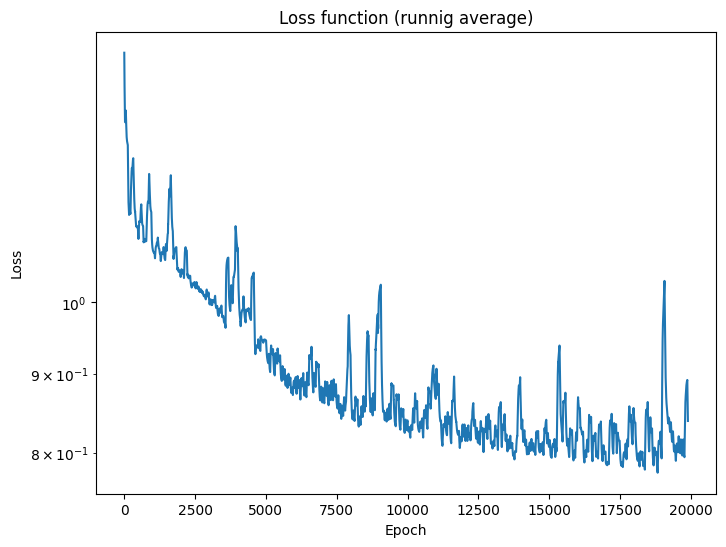

In [18]:
# Loss function
# average_loss = running_average(loss_values, window=100)
average_loss = running_average(history['total'], window=100)
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
ax.set_title("Loss function (runnig average)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.plot(average_loss)
ax.set_yscale('log')

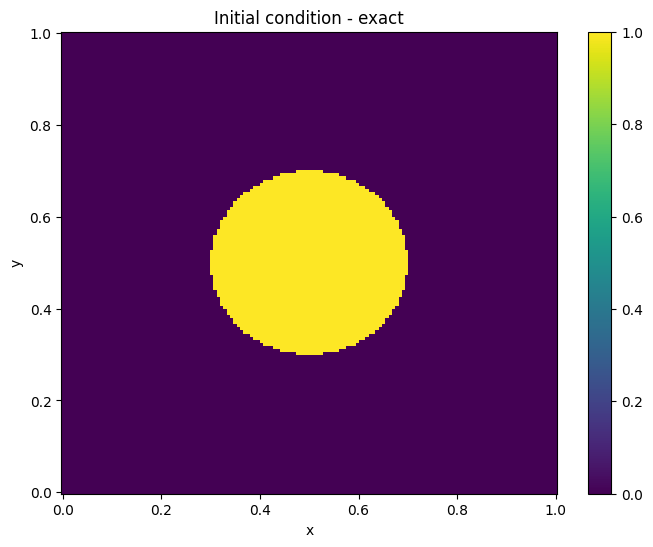

In [20]:
x, y, _ = get_initial_points(x_domain, y_domain, t_domain, N_POINTS_PLOT, requires_grad=False)
z = initial_condition(x, y)
fig = plot_color(z, x, y, N_POINTS_PLOT, N_POINTS_PLOT, "Initial condition - exact")

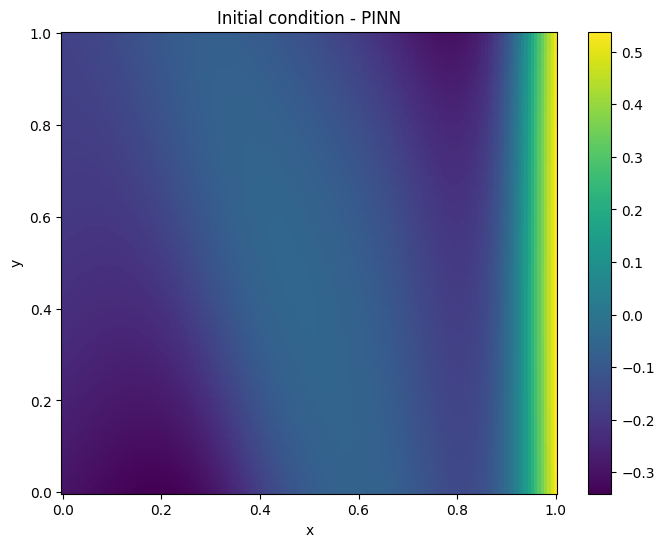

In [21]:
t_value = 0.0
t = torch.full_like(x, t_value)
z = pinn(x, y, t)
fig = plot_color(z, x, y, N_POINTS_PLOT, N_POINTS_PLOT, "Initial condition - PINN")

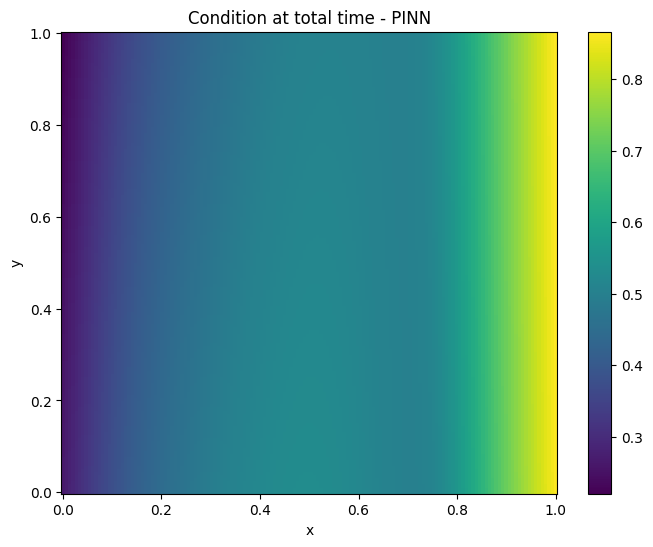

In [22]:
t_value = TOTAL_TIME
t = torch.full_like(x, t_value)
z = pinn(x, y, t)
fig = plot_color(z, x, y, N_POINTS_PLOT, N_POINTS_PLOT, "Condition at total time - PINN")

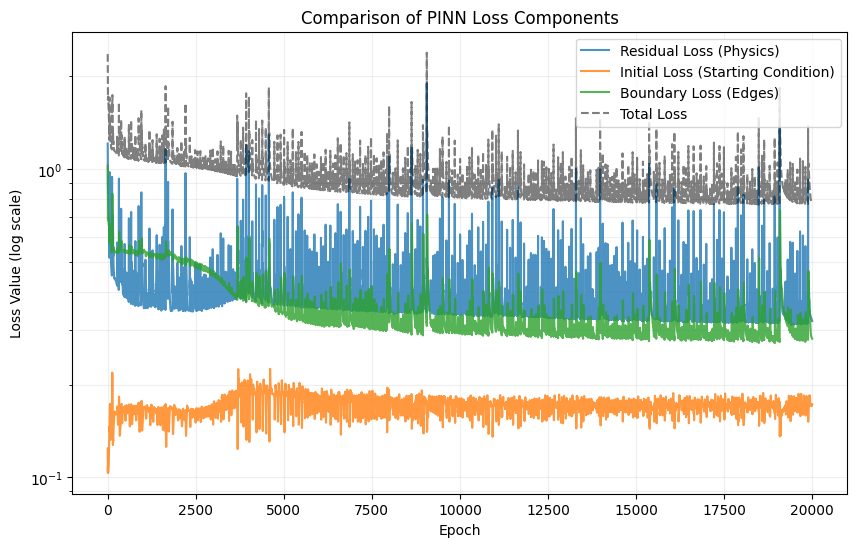

In [28]:
def plot_loss_comparison(history):
    plt.figure(figsize=(10, 6), dpi=100)

    epochs = range(1, len(history['total']) + 1)

    plt.plot(epochs, history['residual'], label='Residual Loss (Physics)', alpha=0.8)
    plt.plot(epochs, history['initial'], label='Initial Loss (Starting Condition)', alpha=0.8)
    plt.plot(epochs, history['boundary'], label='Boundary Loss (Edges)', alpha=0.8)

    plt.plot(epochs, history['total'], label='Total Loss', color='black', linestyle='--', alpha=0.5)

    plt.yscale('log')
    plt.title("Comparison of PINN Loss Components")
    plt.xlabel("Epoch")
    plt.ylabel("Loss Value (log scale)")
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.show()

plot_loss_comparison(history)